# AOS_hack_04_2026


https://rubinobs.atlassian.net/wiki/spaces/LTS/pages/1573126156/Focused+Efforts+and+Tasks


* Update donut plot changing units in M2 rx/ry (asec instead of deg)
* Add donut quality of fit to donutFits plots and to WEP, and report on how many sub-class donuts we have been using so far


## Update M2/ camera tilt units 
First need to check whether tilt is  already stored as asec, or do I need to convert from deg:

https://rubinobs.atlassian.net/browse/DM-54584

ok, it's using the same code as nightly report 

https://github.com/lsst-so/ts_aos_analysis/blob/develop/notebooks/nightly_report/nightly_report_detailed.ipynb


which gets the states via 

      event = getMostRecentRowWithDataBefore(
                    self.efd_client,
                    "lsst.sal.MTAOS.logevent_degreeOfFreedom",
                    timeToLookBefore=rec_start,
                )
                out = np.empty(
                    50,
                )
                for i in range(50):
                    out[i] = event[f"aggregatedDoF{i}"]
                states_val = out

    states.append(states_val)

    # -- Next column: Mirror mode plots with shared x-axis (not y)
    axes1 = [fig.add_subplot(gs_top[i, 2]) for i in range(6)]
    axes2 = [fig.add_subplot(gs_bot[i, 2]) for i in range(6)]
    axes = axes1 + axes2
    indices = list(range(10, 17)) + list(range(30,35))
    for n, i in enumerate(indices):
        vals = dof_state[:, i]
        axes[n].scatter(seqs, vals, s=11)
        axes[n].set_ylabel(all_labels[i])
    for ax in axes:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    axes[0].set_title(f'Mirror DOFs (Trim only)')

and the labels already have `'M2 tilts\n[arcsec]',` , so I think what's stored in EFD for M2 tilts is already in asec ... 

This is the night report from 20260402 https://rubin-obs.slack.com/files/U07QE7YLK96/F0ARKRB9K08/full_night_report_20260402.png

This section of the report focuses on the hexapods state: 

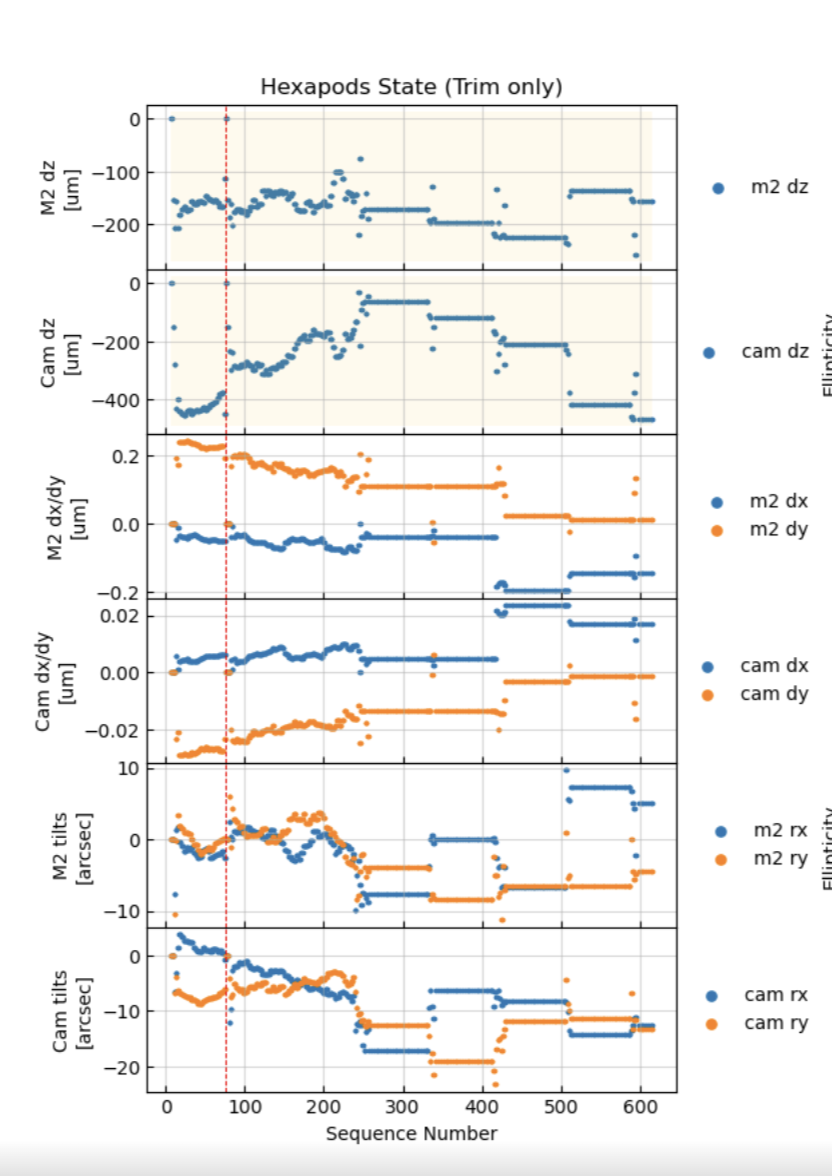

This code reproduces the query to illustrate what needs to happen to EFD data to look the same:

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from lsst.summit.utils.efdUtils import makeEfdClient, getMostRecentRowWithDataBefore

client = makeEfdClient()
topic = "lsst.sal.MTAOS.logevent_degreeOfFreedom"

day_obs = 20260402  # adjust
seq_nums = range(0, 650)  # adjust

# Rigid body labels and indices
rigid_labels = [
    "M2 dz [um]", "M2 dx [um]", "M2 dy [um]", "M2 rx", "M2 ry",
    "Cam dz [um]", "Cam dx", "Cam dy", "Cam rx", "Cam ry",
]

# You'll need visit start times. If you have a butler:
from lsst.daf.butler import Butler
butler = Butler("LSSTCam", collections = ['LSSTCam/raw/all'])  # adjust
results = {}

for seq in seq_nums:
    exposure_id  = day_obs * 100000 + seq  # adjust ID construction if needed
    try:
        refs = list(butler.registry.queryDatasets('raw',  day_obs = day_obs, detector=191,                            
     where=f"instrument='LSSTCam' and exposure.id = {exposure_id}",).expanded() 
           )
        timespan = refs[0].dataId.records['exposure'].timespan
        t = Time(timespan.begin, scale="utc")
        event = getMostRecentRowWithDataBefore(client, topic, timeToLookBefore=t)
        results[seq] = [event[f"aggregatedDoF{i}"] for i in range(10)]
    except Exception as e:
        print(f"seq {seq}: {e}")


data = np.array([results[s] for s in sorted(results)])
seqs = sorted(results.keys())

seq 0: list index out of range


/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.1.0-exact/lib/python3.13/json/decoder.py:361: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  obj, end = self.scan_once(s, idx)


seq 643: list index out of range
seq 644: list index out of range
seq 645: list index out of range
seq 646: list index out of range
seq 647: list index out of range
seq 648: list index out of range
seq 649: list index out of range


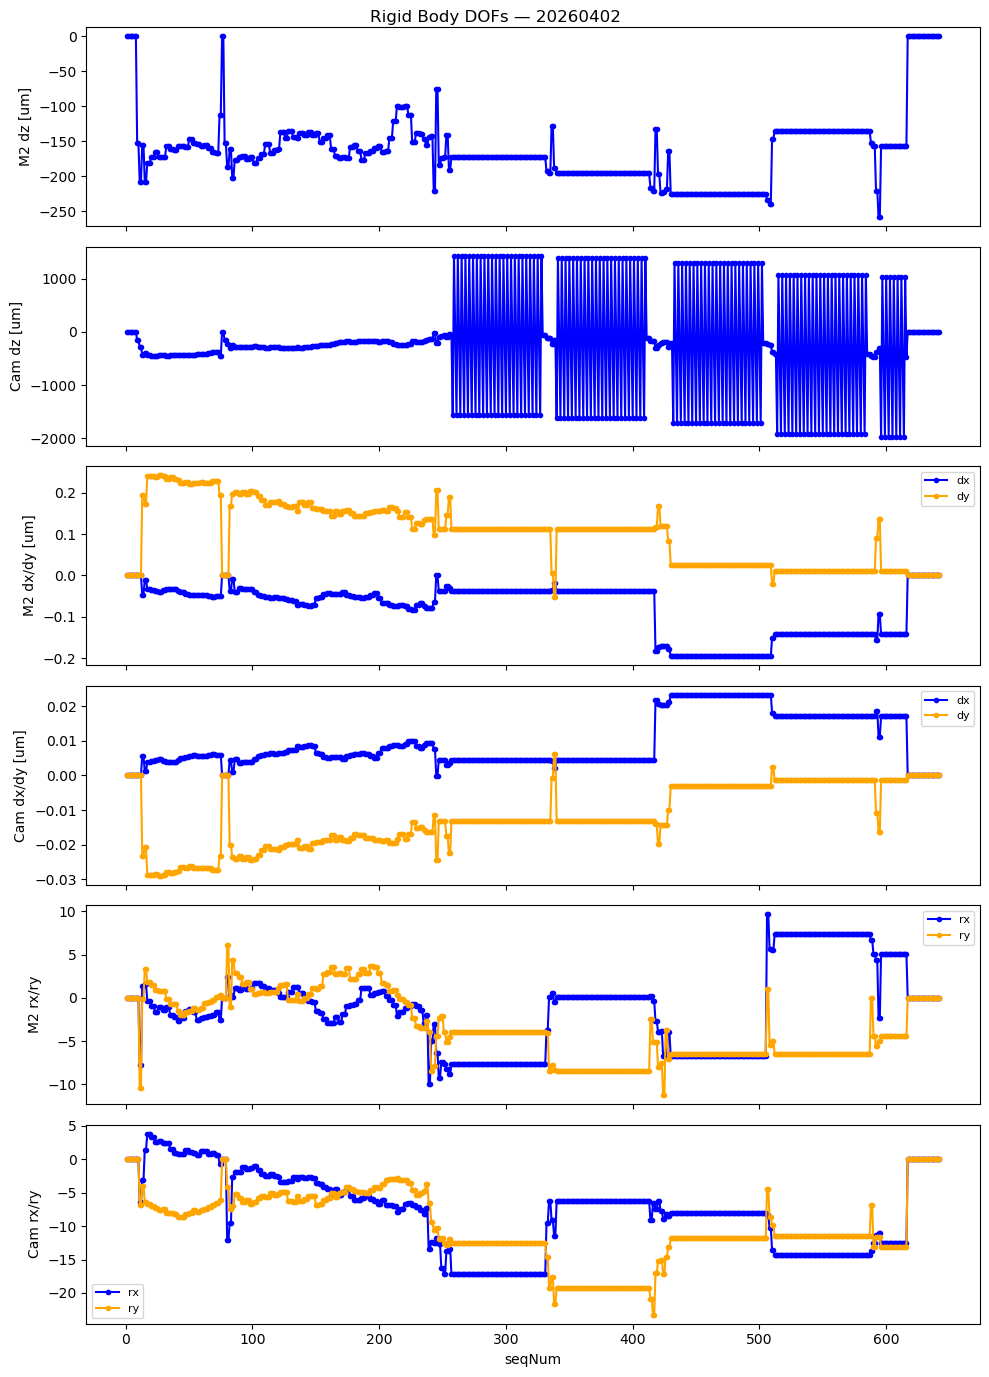

In [15]:
# Plot
fig, axes = plt.subplots(6, 1, figsize=(10, 14), sharex=True)

# Row 0: M2 dz
axes[0].plot(seqs, data[:, 0], ".-", color="blue")
axes[0].set_ylabel("M2 dz [um]")

# Row 1: Cam dz
axes[1].plot(seqs, data[:, 5], ".-", color="blue")
axes[1].set_ylabel("Cam dz [um]")

# Row 2: M2 dx, dy
axes[2].plot(seqs, data[:, 1], ".-", color="blue", label="dx")
axes[2].plot(seqs, data[:, 2], ".-", color="orange", label="dy")
axes[2].set_ylabel("M2 dx/dy [um]")
axes[2].legend(fontsize=8)

# Row 3: Cam dx, dy
axes[3].plot(seqs, data[:, 6], ".-", color="blue", label="dx")
axes[3].plot(seqs, data[:, 7], ".-", color="orange", label="dy")
axes[3].set_ylabel("Cam dx/dy [um]")
axes[3].legend(fontsize=8)

# Row 4: M2 rx, ry
axes[4].plot(seqs, data[:, 3]*3600, ".-", color="blue", label="rx")
axes[4].plot(seqs, data[:, 4]*3600, ".-", color="orange", label="ry")
axes[4].set_ylabel("M2 rx/ry")
axes[4].legend(fontsize=8)

# Row 5: Cam rx, ry
axes[5].plot(seqs, data[:, 8]*3600, ".-", color="blue", label="rx")
axes[5].plot(seqs, data[:, 9]*3600, ".-", color="orange", label="ry")
axes[5].set_ylabel("Cam rx/ry")
axes[5].legend(fontsize=8)

axes[-1].set_xlabel("seqNum")
fig.suptitle(f"Rigid Body DOFs — {day_obs}")
plt.tight_layout()
plt.show()

Same conversion is done here https://github.com/lsst-so/ts_aos_analysis/blob/develop/notebooks/nightly_report/nightly_report_detailed.ipynb

     if i in [3, 4, 8, 9]:
                vals *= 3600
            ax.scatter(seqs, vals, label=f"{labels[i]}", s=9

and these labels 

                group_labels = ['M2 dz\n[um]', 'Cam dz\n[um]', 'M2 dx/dy\n[um]', 'Cam dx/dy\n[um]', 'M2 tilts\n[arcsec]', 'Cam tilts\n[arcsec]']

are indeed telling me that these are now plotted in asec. 

M2 rx (asec)               raw(deg):    -0.000425  converted(asec):       -1.529
M2 ry (asec)               raw(deg):     0.000287  converted(asec):        1.033
Camera rx (asec)           raw(deg):    -0.000992  converted(asec):       -3.572
Camera ry (asec)           raw(deg):    -0.001917  converted(asec):       -6.902


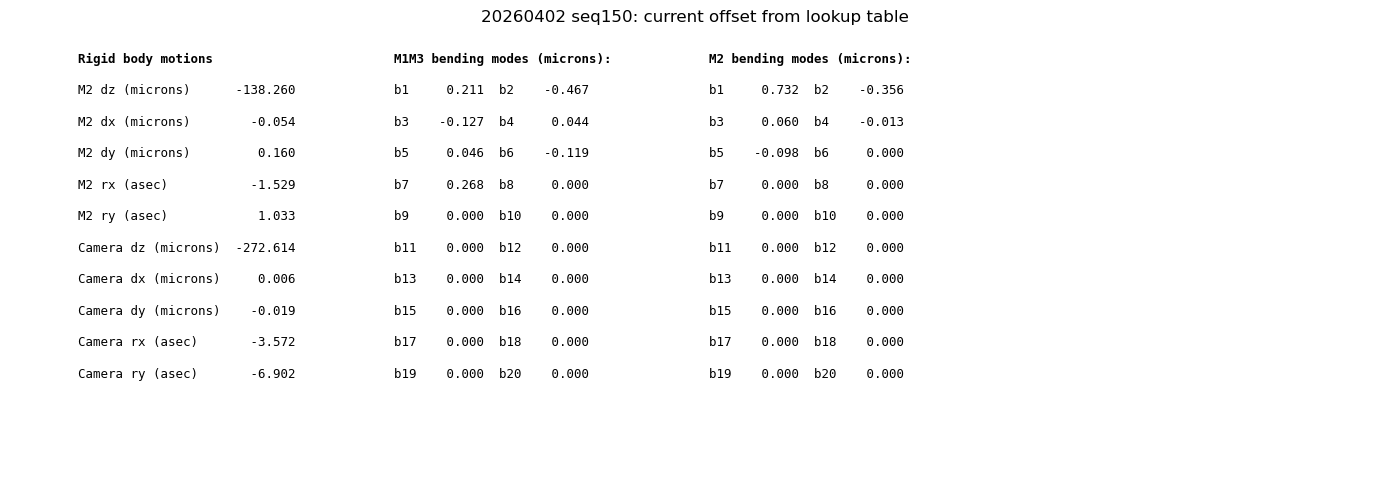

In [71]:
import numpy as np
from astropy.time import Time
from lsst.summit.utils.efdUtils import makeEfdClient, getMostRecentRowWithDataBefore

client = makeEfdClient()
topic = "lsst.sal.MTAOS.logevent_degreeOfFreedom"

# Pick a specific exposure to test
day_obs = 20260402
seq_num = 150  # adjust to a known good seq

# Get the EFD event (you'll need a timestamp - reuse your butler lookup)
from lsst.daf.butler import Butler
butler = Butler("LSSTCam", collections=['LSSTCam/raw/all'])
exposure_id = day_obs * 100000 + seq_num
refs = list(butler.registry.queryDatasets(
    'raw', day_obs=day_obs, detector=191,
    where=f"instrument='LSSTCam' and exposure.id = {exposure_id}"
).expanded())
timespan = refs[0].dataId.records['exposure'].timespan
t = Time(timespan.begin, scale="utc")

event = getMostRecentRowWithDataBefore(client, topic, timeToLookBefore=t)
states_val = np.array([event[f"aggregatedDoF{i}"] for i in range(50)])

# --- Now reproduce the bottom panel ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xticks([]); ax.set_yticks([])
ax.set_frame_on(False)
ax.set_title(f"{day_obs} seq{seq_num}: current offset from lookup table")

rigid_groups = [
    ("M2 dz (microns)", [0]),
    ("M2 dx (microns)", [1]),
    ("M2 dy (microns)", [2]),
    ("M2 rx (asec)",    [3]),
    ("M2 ry (asec)",    [4]),
    ("Camera dz (microns)", [5]),
    ("Camera dx (microns)", [6]),
    ("Camera dy (microns)", [7]),
    ("Camera rx (asec)",    [8]),
    ("Camera ry (asec)",    [9]),
]

bending_groups = [
    ("M1M3 bending modes (microns)", list(range(10, 30))),
    ("M2 bending modes (microns)",   list(range(30, 50))),
]

col_xpos = [0.05, 0.28, 0.51, 0.72]
y_start = 0.95
y_step = 0.07

# Precompute values with conversion
display_vals = states_val.copy()
for i in [3, 4, 8, 9]:
    display_vals[i] *= 3600  # deg -> asec

rigid_vals = [display_vals[i] for _, idxs in rigid_groups for i in idxs]
formatted_all = [f"{v:.3f}" for v in rigid_vals]
int_parts = [f.split(".")[0] for f in formatted_all]
max_int_rigid = max(len(ip) for ip in int_parts)

ypos = {0: y_start, 1: y_start, 2: y_start, 3: y_start}

ax.text(col_xpos[0], ypos[0], "Rigid body motions",
        transform=ax.transAxes, fontsize=9, va="top", ha="left",
        family="monospace", weight="bold")
ypos[0] -= y_step

for label, idxs in rigid_groups:
    val = display_vals[idxs[0]]
    formatted_str = f"{val:.3f}"
    ip, fp = formatted_str.split(".")
    line = f"{label:<20} {ip:>{max_int_rigid}}.{fp}"
    ax.text(col_xpos[0], ypos[0], line,
            transform=ax.transAxes, fontsize=9, va="top", ha="left",
            family="monospace")
    ypos[0] -= y_step

# Also print raw vs converted for quick sanity check
for label, idxs in rigid_groups:
    i = idxs[0]
    if i in [3, 4, 8, 9]:
        print(f"{label:25s}  raw(deg): {states_val[i]:12.6f}  converted(asec): {states_val[i]*3600:12.3f}")

for gi, (label, idxs) in enumerate(bending_groups):
    col = gi + 1
    vals = [states_val[j] for j in idxs]
    ax.text(col_xpos[col], ypos[col], f"{label}:",
            transform=ax.transAxes, fontsize=9, va="top", ha="left",
            family="monospace", weight="bold")
    ypos[col] -= y_step
    for j in range(0, len(vals), 2):
        parts = []
        for k in range(2):
            if j+k < len(vals):
                v = vals[j+k]
                parts.append(f"b{j+k+1:<2} {v:8.3f}")
        ax.text(col_xpos[col], ypos[col], "  ".join(parts),
                transform=ax.transAxes, fontsize=9, va="top", ha="left",
                family="monospace")
        ypos[col] -= y_step

plt.tight_layout()
plt.show()

## Add chi2 / fractional residual measure to plotDonutFits

Try to use the AOS dataset at USDF to test running `plotDonutFits` in the notebook:

In [83]:

butler = Butler('LSSTCam', collections=['aos_cwfs_danish'])


refs = list(butler.registry.queryDatasets('aggregateAOSVisitTableRaw',  
                                          detector=191,                   
     where="instrument='LSSTCam'  and day_obs > 20260127",).expanded() 
           )
len(refs)





195

In [88]:
butler = Butler('embargo', 
                collections=['aos_cwfs_danish_triplets_infocus'],
               )
refs = list(butler.registry.queryDatasets('aggregateAOSVisitTableRaw',
                                     where="instrument='LSSTCam'  and day_obs > 20260220",).expanded() 
           )      
len(refs)

181

In [98]:
min(np.array([ref.dataId.day_obs.id for ref in refs]))

np.int64(20260315)

In [100]:
max(np.array([ref.dataId.day_obs.id for ref in refs]))

np.int64(20260317)

ok, let's use data from 2026-03-17

In [110]:
butler = Butler('embargo', 
                collections=['aos_cwfs_danish_triplets_infocus'],
               )
day_obs = 20260317
seq = 279
visit_id =  day_obs * 100000 + seq
refs = list(butler.registry.queryDatasets('aggregateAOSVisitTableRaw', day_obs = day_obs,
                                     where=f"instrument='LSSTCam' and visit = {visit_id} ",).expanded() 
           )      
len(refs)

1

In [111]:
refs = list(butler.registry.queryDatasets('donutStampsExtraVisit', day_obs = day_obs,
                                     where=f"instrument='LSSTCam' and visit = {visit_id} ",).expanded() 
           )      
len(refs)

1

In [1]:
import numpy as np
import yaml
import danish
import galsim
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap


In [2]:
danish.__version__

'1.0.0'

  R00 donut 0 extra: reduced_chi2=6685.72  fractional res =0.7444794985814079
  R00 donut 0 intra: reduced_chi2=1120.62  fractional res =0.7448382038388071
  R00 donut 1 extra: reduced_chi2=1547.20  fractional res =0.7433233178937989
  R00 donut 1 intra: reduced_chi2=861.77  fractional res =0.7465058029401785
  R00 donut 2 extra: reduced_chi2=529.85  fractional res =0.7457671057507117
  R00 donut 2 intra: reduced_chi2=471.28  fractional res =0.7491125262825473
  R00 donut 3 extra: reduced_chi2=232.13  fractional res =0.7536231587444637
  R00 donut 3 intra: reduced_chi2=9.40  fractional res =0.7779369539536726
  R00 donut 4 extra: reduced_chi2=175.63  fractional res =0.7554890254033948
  R00 donut 4 intra: reduced_chi2=2.52  fractional res =0.7956195181868764
  R00 donut 5 extra: reduced_chi2=127.60  fractional res =0.7543825293099534
  R00 donut 5 intra: reduced_chi2=130.06  fractional res =0.7612401585901098
  R00 donut 6 extra: reduced_chi2=108.79  fractional res =0.7577166127343966


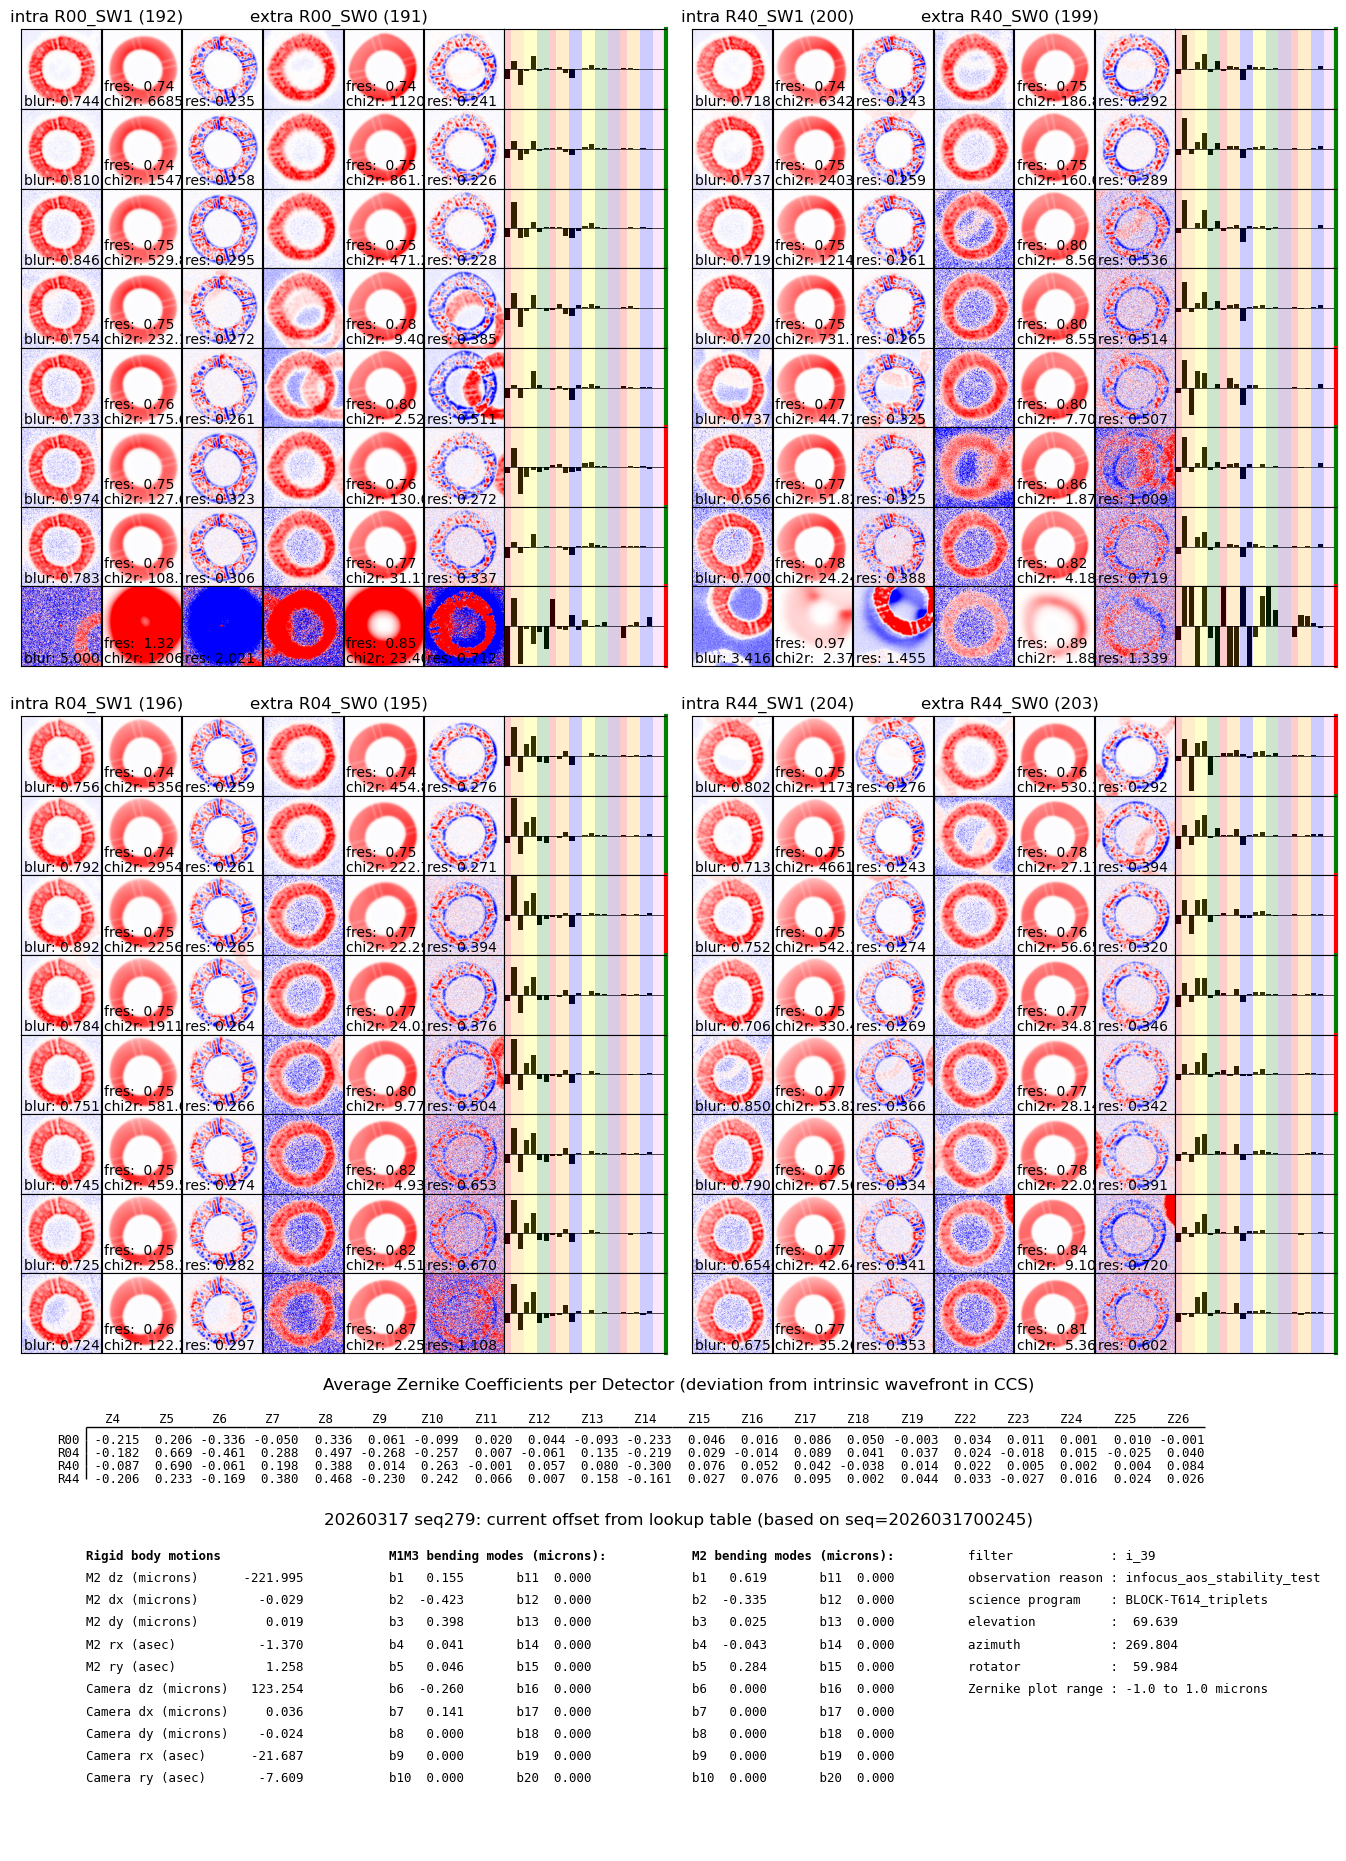

In [6]:
import numpy as np
import yaml
import danish
import galsim
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.figure import Figure
from astropy.coordinates import Angle
from astropy.table import Table
from astropy.time import Time
from lsst.daf.butler import Butler
from lsst.obs.lsst import LsstCam
from lsst.ts.wep.estimation import DanishAlgorithm
from lsst.ts.wep.utils import getTaskInstrument
from lsst.summit.utils.efdUtils import (
    getEfdData, getMostRecentRowWithDataBefore, makeEfdClient,
)

galsim.errors.raise_fft_size_error = True

# --- Config ---
day_obs = 20260317
seq_num = 279  # adjust
ndonuts = 8
zkYmin = -1.0
zkYmax = 1.0

butler = Butler("embargo", collections=[
    "LSSTCam/raw/all",
    "LSSTCam/calib",
    "aos_cwfs_danish_triplets_infocus",  # adjust to your AOS collection
])




# --- Find visit ---
exposure_id = day_obs * 100000 + seq_num
refs = list(butler.registry.queryDatasets(
    'raw', day_obs=day_obs, detector=191,
    where=f"instrument='LSSTCam' and exposure.id = {exposure_id}"
).expanded())
visit_id = refs[0].dataId.records['exposure'].id
record = refs[0].dataId.records['exposure']
dataId = {"instrument": "LSSTCam", "visit": visit_id}

# --- Load butler products ---
aos_raw = butler.get("aggregateAOSVisitTableRaw", dataId=dataId)
donutStampsIntra = butler.get("donutStampsIntraVisit", dataId=dataId)
donutStampsExtra = butler.get("donutStampsExtraVisit", dataId=dataId)
camera = LsstCam().getCamera()

# --- Setup danish ---
mask_params_fn = Path(danish.datadir) / "RubinObsc.yaml"
with open(mask_params_fn) as f:
    mask_params = yaml.safe_load(f)

instrument = getTaskInstrument("LSSTCam", "R00_SW0", None)
obsc = instrument.obscuration
focal_length = instrument.focalLength
r_outer = instrument.radius
pixel_scale = instrument.pixelSize

def get_rtp(donutStamps):
    metadata = donutStamps.metadata
    try:
        rsp = metadata["BORESIGHT_ROT_ANGLE_RAD"]
        q = metadata["BORESIGHT_PAR_ANGLE_RAD"]
    except KeyError:
        return Angle(np.nan, "rad")
    return Angle(q - rsp - np.pi / 2, "rad")

rtp = get_rtp(donutStampsExtra)

factory = danish.DonutFactory(
    R_outer=r_outer, R_inner=r_outer * obsc,
    mask_params=mask_params, focal_length=focal_length,
    pixel_scale=pixel_scale, spider_angle=rtp.deg,
)

danish_algo = DanishAlgorithm()
danish_model_keys = ["fwhm", "model_bkg", "model_dx", "model_dy", "model_flux"]
noll_indices = aos_raw.meta["nollIndices"]

# --- EFD data ---
efd_client = makeEfdClient()
startTime = record.timespan.begin
endTime = record.timespan.end

states_val = np.empty(50)
visit_logevent = "unknown"
if day_obs > 20250101:
    event = getMostRecentRowWithDataBefore(
        efd_client, "lsst.sal.MTAOS.logevent_degreeOfFreedom",
        timeToLookBefore=Time(startTime, scale="utc"),
    )
    for i in range(50):
        states_val[i] = event[f"aggregatedDoF{i}"]
    if "visitId" in event.keys():
        visit_logevent = event["visitId"]

rotData = getEfdData(
    client=efd_client, topic="lsst.sal.MTRotator.rotation",
    begin=startTime, end=endTime,
)


# --- chi2 ---
def compute_chi2(img, model, background_std, gain=1.0):
    bg_var = background_std**2
    model_var = np.clip(model, 0, None) / gain
    variance = model_var + bg_var
    mask = variance > 0
    chi2 = np.sum((img[mask] - model[mask])**2 / variance[mask])
    ndof = int(np.sum(mask)) - 1
    rchi2 = chi2 / ndof if ndof > 0 else np.nan
    return chi2, rchi2, ndof


# --- getModel ---
def get_model(zk_deviation_ccs, zk_intrinsic_ccs, noll_indices, danish_meta,
              stamp_extra, stamp_intra):
    zk_dev = zk_deviation_ccs * 1e-6
    zk_int = zk_intrinsic_ccs * 1e-6
    dz_terms = [(1, j) for j in noll_indices]

    img_extra, angle_extra, zkRef_extra, bgStd_extra = danish_algo._prepDanish(
        image=stamp_extra.wep_im, zkStart=zk_int,
        nollIndices=noll_indices, instrument=instrument)
    img_intra, angle_intra, zkRef_intra, bgStd_intra = danish_algo._prepDanish(
        image=stamp_intra.wep_im, zkStart=zk_int,
        nollIndices=noll_indices, instrument=instrument)

    zk_fit = zk_dev - zk_int
    nbkg = danish_meta["model_bkg"].shape[1]
    bkg_order = int(np.sqrt(9 + 8 * (nbkg - 1)) - 3) // 2

    model = danish.DZMultiDonutModel(
        factory, z_refs=[zkRef_extra, zkRef_intra],
        dz_terms=dz_terms, field_radius=np.deg2rad(1.81),
        thxs=[angle_extra[0], angle_intra[0]],
        thys=[angle_extra[1], angle_intra[1]],
        npix=img_extra.shape[0], bkg_order=bkg_order,
    )
    bkgs = [tuple(bkg) for bkg in danish_meta["model_bkg"]]
    try:
        model_images = model.model(
            danish_meta["model_flux"], danish_meta["model_dx"],
            danish_meta["model_dy"], danish_meta["fwhm"],
            zk_fit, bkgs=bkgs,
        )
    except (galsim.GalSimFFTSizeError, ValueError) as e:
        if isinstance(e, galsim.GalSimFFTSizeError) or "cannot convert float NaN to integer" in str(e):
            print(f"  WARNING: model failed: {e}")
            model_images = [np.zeros_like(img_extra), np.zeros_like(img_intra)]
        else:
            raise
    return ([img_extra, img_intra], model_images, [bgStd_extra, bgStd_intra])


def compute_residual_stats(img, model):
    res = img - model
    pos_res = np.sum(np.abs(res[res > 0]))
    neg_res = np.sum(np.abs(res[res < 0]))
    tot_res = np.sum(np.abs(res))
    return pos_res, neg_res, tot_res

def compute_fractional_residual(img, model):
    """Fractional residual: sum(|img - model|) / sum(img).
    
    Values closer to 0 mean better fits.
    Typically ~0.05-0.10 for good fits, >0.2 for bad fits.
    """
    total_flux = np.sum(np.abs(img))
    if total_flux == 0:
        return np.nan
    return np.sum(np.abs(img - model)) / total_flux

    
# =====================================================================
# BUILD THE FIGURE — exactly like the task
# =====================================================================
colors = [(0, 0, 1), (1, 1, 1), (1, 0, 0)]
positions = [0.0, 1/11, 1.0]
cmap = LinearSegmentedColormap.from_list("bwr_custom", list(zip(positions, colors)))

ncols_donut = 7
cell_size = 1.0
raft_width = ncols_donut * cell_size
raft_height = ndonuts * cell_size
fig_height = 2 * raft_height + 3.8
fig_width = 2 * raft_width

fig = plt.figure(figsize=(fig_width, fig_height))
axdict = {}
gs0 = GridSpec(
    nrows=4, ncols=2,
    left=0.03, right=0.97, bottom=0.03, top=0.95,
    wspace=0.04, hspace=0.12,
    height_ratios=[4, 4, 0.5, 2],
)

for i, j, raft in [(0, 0, "R00"), (0, 1, "R40"), (1, 0, "R04"), (1, 1, "R44")]:
    gs1 = GridSpecFromSubplotSpec(
        nrows=ndonuts, ncols=1, subplot_spec=gs0[i, j],
        wspace=0.0, hspace=0.0,
    )
    axdict[raft] = []
    for k in range(ndonuts):
        gs2 = GridSpecFromSubplotSpec(
            nrows=1, ncols=7, subplot_spec=gs1[k],
            wspace=0.0, hspace=0.0,
            width_ratios=[1, 1, 1, 1, 1, 1, 2],
        )
        axs = []
        for ls in range(7):
            ax = fig.add_subplot(gs2[0, ls])
            ax.set_xticks([]); ax.set_yticks([])
            axs.append(ax)
        axdict[raft].append(axs)

middle_ax = fig.add_subplot(gs0[2, :])
middle_ax.set_xticks([]); middle_ax.set_yticks([])

bottom_ax = fig.add_subplot(gs0[3, :])
bottom_ax.set_xticks([]); bottom_ax.set_yticks([])

donut_blur = np.zeros(len(aos_raw))
if "fwhm" in aos_raw.meta["estimatorInfo"].keys():
    donut_blur = np.array(aos_raw.meta["estimatorInfo"].get("fwhm"))

# --- Proceed raft by raft ---
for iraft, raft in enumerate(["R00", "R04", "R40", "R44"]):
    detname = raft + "_SW0"
    selected_rows = aos_raw["detector"] == detname
    rows = aos_raw[selected_rows]
    blur = donut_blur[selected_rows]
    if len(rows) == 0:
        continue

    for defocal, sw, col in zip(["intra", "extra"], ["SW1", "SW0"], [0, 3]):
        raftName = f"{raft}_{sw}"
        detId = camera.get(raftName).getId()
        axdict[raft][0][col].set_title(f"{defocal} {raftName} ({detId})", x=0.95)

    idxIntra = np.array(donutStampsIntra.metadata.getArray("DET_NAME")) == f"{raft}_SW1"
    stampsIntraSel = np.array(donutStampsIntra)[idxIntra]
    intra_x = [s.centroid_position.x for s in stampsIntraSel]
    intra_y = [s.centroid_position.y for s in stampsIntraSel]

    idxExtra = np.array(donutStampsExtra.metadata.getArray("DET_NAME")) == f"{raft}_SW0"
    stampsExtraSel = np.array(donutStampsExtra)[idxExtra]
    extra_x = [s.centroid_position.x for s in stampsExtraSel]
    extra_y = [s.centroid_position.y for s in stampsExtraSel]

    raft_meta = {
        key: np.array(value)[selected_rows]
        for key, value in aos_raw.meta["estimatorInfo"].items()
    }

    nrows_plot = min(ndonuts, len(rows))

    for irow, row in enumerate(rows[:nrows_plot]):
        dists = np.hypot(np.array(intra_x) - row["centroid_x_intra"],
                         np.array(intra_y) - row["centroid_y_intra"])
        intra_stamp = stampsIntraSel[np.argmin(dists)]

        dists = np.hypot(np.array(extra_x) - row["centroid_x_extra"],
                         np.array(extra_y) - row["centroid_y_extra"])
        extra_stamp = stampsExtraSel[np.argmin(dists)]

        necessary_keys = set(danish_model_keys)
        available_keys = set(row.meta["estimatorInfo"].keys())
        if available_keys & necessary_keys != necessary_keys:
            missing = necessary_keys - available_keys
            print(f"  Skipping {raft} donut {irow}: missing {sorted(missing)}")
            continue

        dmeta = {key: value[irow] for key, value in raft_meta.items()}
        imgs, model_imgs, bg_stds = get_model(
            row["zk_deviation_CCS"], row["zk_intrinsic_CCS"],
            noll_indices, dmeta, extra_stamp, intra_stamp)
            
        # --- Chi2 before normalization ---
        rchi2_vals = []
        # --- Fractional residual before normalization ---
        fres_vals = []
        for k, (im, mod, bg, label) in enumerate(zip(
                imgs, model_imgs, bg_stds, ["extra", "intra"])):
            chi2, rchi2, ndof = compute_chi2(im, mod, bg)
            rchi2_vals.append(rchi2)
            
            fres = compute_fractional_residual(im, mod)
            fres_vals.append(fres)
            print(f"  {raft} donut {irow} {label}: "
                  f"reduced_chi2={rchi2:.2f}  fractional res ={fres}")

        # Normalize
        for k in range(2):
            s = np.sum(imgs[k])
            if s > 0: imgs[k] /= s
            s = np.sum(model_imgs[k])
            if s > 0: model_imgs[k] /= s

        # --- plotResults ---
        axs = axdict[raft][irow]
        vmax = np.nanquantile(imgs[0], 0.99)
        axs[0].imshow(imgs[0], cmap=cmap, vmin=-vmax/10, vmax=vmax)
        axs[0].text(5, 150, f"blur: {blur[irow]:5.3f}")
        axs[1].imshow(model_imgs[0], cmap=cmap, vmin=-vmax/10, vmax=vmax)
        axs[1].text(5, 150, f"chi2r: {rchi2_vals[0]:5.2f}")
        axs[1].text(5, 120, f"fres: {fres_vals[0]:5.2f}")
        axs[2].imshow(imgs[0] - model_imgs[0], cmap="bwr", vmin=-vmax/3, vmax=vmax/3)
        _, _, ttl_res = compute_residual_stats(imgs[0], model_imgs[0])
        axs[2].text(5, 150, f"res: {ttl_res:5.3f}")
        axs[3].imshow(imgs[1], cmap=cmap, vmin=-vmax/10, vmax=vmax)
        axs[4].imshow(model_imgs[1], cmap=cmap, vmin=-vmax/10, vmax=vmax)
        axs[4].text(5, 150, f"chi2r: {rchi2_vals[1]:5.2f}")
        axs[4].text(5, 120, f"fres: {fres_vals[1]:5.2f}")
        axs[5].imshow(imgs[1] - model_imgs[1], cmap="bwr", vmin=-vmax/3, vmax=vmax/3)
        _, _, ttl_res = compute_residual_stats(imgs[1], model_imgs[1])
        axs[5].text(5, 150, f"res: {ttl_res:5.3f}")

        axs[6].bar(noll_indices, row["zk_CCS"], color="k")
        axs[6].axhline(0, color="k", lw=0.5)
        axs[6].set_ylim(zkYmin, zkYmax)
        axs[6].set_xlim(3.5, 28.5)
        
        # Zernike type markers
        axs[6].scatter([4, 11, 22], [2.2]*3, marker="o", ec="k", c="none", s=10, lw=0.5)
        axs[6].scatter([7, 17], [2.2]*2, marker="$\u2191$", c="k", s=10, lw=0.5)
        axs[6].scatter([8, 16], [2.2]*2, marker="$\u2192$", c="k", s=10, lw=0.5)
        axs[6].scatter([5, 13, 23], [2.2]*3, marker=(2,2,45), c="k", s=10, lw=0.5)
        axs[6].scatter([6, 12, 24], [2.2]*3, marker=(2,2,90), c="k", s=10, lw=0.5)
        axs[6].scatter([9, 19], [2.2]*2, marker=(3,2,60), c="k", s=10, lw=0.5)
        axs[6].scatter([10, 18], [2.2]*2, marker=(3,2,30), c="k", s=10, lw=0.5)
        axs[6].scatter([14, 26], [2.2]*2, marker=(4,2), c="k", s=10, lw=0.5)
        axs[6].scatter([15, 25], [2.2]*2, marker=(4,2,22.5), c="k", s=10, lw=0.5)
        axs[6].scatter([20], [2.2], marker=(5,2,-18), c="k", s=10, lw=0.5)
        axs[6].scatter([21], [2.2], marker=(5,2), c="k", s=10, lw=0.5)
        axs[6].scatter([27], [2.2], marker=(6,2,15), c="k", s=10, lw=0.5)
        axs[6].scatter([28], [2.2], marker=(6,2), c="k", s=10, lw=0.5)
        for j in [4, 11, 22]:
            axs[6].axvspan(j-0.5, j+0.5, color="red", alpha=0.2, ec="none")
        for j in [5, 12, 23]:
            axs[6].axvspan(j-0.5, j+1.5, color="orange", alpha=0.2, ec="none")
        for j in [7, 16]:
            axs[6].axvspan(j-0.5, j+1.5, color="yellow", alpha=0.2, ec="none")
        for j in [9, 18]:
            axs[6].axvspan(j-0.5, j+1.5, color="green", alpha=0.2, ec="none")
        for j in [14, 25]:
            axs[6].axvspan(j-0.5, j+1.5, color="blue", alpha=0.2, ec="none")
        axs[6].axvspan(19.5, 21.5, color="indigo", alpha=0.2, ec="none")
        axs[6].axvspan(26.5, 28.5, color="violet", alpha=0.2, ec="none")
        color = "gray"
        if "used" in row.columns:
            color = "green" if row["used"] else "red"
        axs[6].spines["right"].set_edgecolor(color)
        axs[6].spines["right"].set_linewidth(3)

    # turn off unused axes
    if nrows_plot < len(axdict[raft]):
        for j in range(nrows_plot, len(axdict[raft])):
            for ax in axdict[raft][j]:
                ax.axis("off")

# =====================================================================
# MIDDLE AXIS — Average Zernike table
# =====================================================================
mask = aos_raw["used"] if "used" in aos_raw.columns else np.ones(len(aos_raw), dtype="bool")
aos_used = aos_raw[mask]
detectors = np.unique(aos_used["detector"])

zkColname = "zk_deviation_CCS" if "zk_deviation_CCS" in aos_raw.colnames else "zk_CCS"
zkTableTitle = ("(deviation from intrinsic wavefront in CCS)"
                if zkColname == "zk_deviation_CCS"
                else "(as-measured in CCS, including intrinsics)")

tab_rows = []
for det in detectors:
    sel = aos_used["detector"] == det
    mean_zk = np.mean(aos_used[zkColname][sel], axis=0)
    tab_rows.append((det, mean_zk))
tab_avg = Table(rows=tab_rows, names=("detector", "zk_CCS_mean"))

nollIndices = aos_raw.meta["nollIndices"]
max_cols = 26
nollIndices_disp = nollIndices[:max_cols]
col_labels = [f"Z{n}" for n in nollIndices_disp]
row_labels = [det[:3] for det in detectors.data]

table_data = []
for det in detectors:
    mzk = tab_avg["zk_CCS_mean"][tab_avg["detector"] == det][0][:max_cols]
    table_data.append([f"{v:7.3f}" for v in mzk])

bbox = [0.05, 0.05, 0.85, 0.85]
tbl = middle_ax.table(
    cellText=table_data, rowLabels=row_labels, colLabels=col_labels,
    loc="left", cellLoc="center", bbox=bbox,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    cell.get_text().set_fontfamily("monospace")
    if r > 0 and c >= 0:
        cell.get_text().set_horizontalalignment("center")
for (r, c), cell in tbl.get_celld().items():
    cell.visible_edges = ""
    if r == 0: cell.visible_edges += "B"
    if c == -1: cell.visible_edges += "R"
for r in range(1, len(row_labels)+1):
    for c in range(-1, len(col_labels)):
        cell = tbl[(r, c)]
        cell.get_text().set_verticalalignment("top")
        cell.set_height(cell.get_height() * 0.8)
for r in range(1, len(row_labels)+1):
    cell = tbl[(r, -1)]
    cell.get_text().set_horizontalalignment("right")
    cell.PAD = 0.2

middle_ax.axis("off")
middle_ax.set_title(
    f"Average Zernike Coefficients per Detector {zkTableTitle}",
    fontsize=12, pad=10,
)

# =====================================================================
# BOTTOM AXIS — DOF states + exposure record
# =====================================================================
def format_group(vals, label, wrap_width=2, rigid=False,
                 label_width=20, prec=3, max_int=None):
    out = []
    if rigid:
        fs = f"{vals[0]:.{prec}f}"
        ip, fp = fs.split(".")
        if max_int is None: max_int = len(ip)
        out.append(f"{label:<{label_width}} {ip:>{max_int}}.{fp}")
    else:
        n = len(vals)
        labels = [f"b{i+1}" for i in range(n)]
        formatted = [f"{v:.{prec}f}" for v in vals]
        int_parts = [f.split(".")[0] for f in formatted]
        frac_parts = [f.split(".")[1] for f in formatted]
        mi = max(len(ip) for ip in int_parts)
        mf = max(len(fp) for fp in frac_parts)
        tokens = [f"{l:<3} {ip:>{mi}}.{fp:<{mf}}"
                  for l, ip, fp in zip(labels, int_parts, frac_parts)]
        nrows = int(np.ceil(n / wrap_width))
        padded = tokens + [""] * (nrows * wrap_width - n)
        arr = np.array(padded).reshape(nrows, wrap_width, order="F")
        out.append(label + ":")
        for row_arr in arr:
            out.append("  ".join(f"{cell:<15}" for cell in row_arr).rstrip())
    return out

rigid_groups = [
    ("M2 dz (microns)", [0]),
    ("M2 dx (microns)", [1]),
    ("M2 dy (microns)", [2]),
    ("M2 rx (asec)",    [3]),
    ("M2 ry (asec)",    [4]),
    ("Camera dz (microns)", [5]),
    ("Camera dx (microns)", [6]),
    ("Camera dy (microns)", [7]),
    ("Camera rx (asec)",    [8]),
    ("Camera ry (asec)",    [9]),
]
bending_groups = [
    ("M1M3 bending modes (microns)", list(range(10, 30))),
    ("M2 bending modes (microns)",   list(range(30, 50))),
]

# Apply deg->asec conversion
display_vals = states_val.copy()
for i in [3, 4, 8, 9]:
    display_vals[i] *= 3600

bottom_ax.set_frame_on(False)
bottom_ax.set_title(
    f"{day_obs} seq{seq_num}: current offset from lookup table "
    f"(based on seq={visit_logevent})"
)

col_xpos = [0.05, 0.28, 0.51, 0.72]
y_start = 0.95
y_step = 0.07

rigid_vals_list = [display_vals[i] for _, idxs in rigid_groups for i in idxs]
formatted_all = [f"{v:.3f}" for v in rigid_vals_list]
int_parts = [f.split(".")[0] for f in formatted_all]
max_int_rigid = max(len(ip) for ip in int_parts)

ypos = {0: y_start, 1: y_start, 2: y_start, 3: y_start}

bottom_ax.text(col_xpos[0], ypos[0], "Rigid body motions",
               transform=bottom_ax.transAxes, fontsize=9, va="top", ha="left",
               family="monospace", weight="bold")
ypos[0] -= y_step

for label, idxs in rigid_groups:
    val = display_vals[idxs[0]]
    lines = format_group([val], label, rigid=True, max_int=max_int_rigid)
    for line in lines:
        bottom_ax.text(col_xpos[0], ypos[0], line,
                       transform=bottom_ax.transAxes, fontsize=9, va="top",
                       ha="left", family="monospace")
        ypos[0] -= y_step

for gi, (label, idxs) in enumerate(bending_groups):
    col = gi + 1
    vals = [states_val[j] for j in idxs]  # bending modes stay as-is
    lines = format_group(vals, label, wrap_width=2)
    for ji, line in enumerate(lines):
        bottom_ax.text(col_xpos[col], ypos[col], line,
                       transform=bottom_ax.transAxes, fontsize=9, va="top",
                       ha="left", family="monospace",
                       weight="bold" if ji == 0 else "normal")
        ypos[col] -= y_step

# Exposure record column
records_dict = {
    "filter": record.physical_filter,
    "observation reason": record.observation_reason,
    "science program": record.science_program,
    "elevation": (90 if record.zenith_angle is None else 90 - record.zenith_angle),
    "azimuth": 0 if record.azimuth is None else record.azimuth,
    "rotator": (0 if len(rotData) == 0 else rotData["actualPosition"].values.mean()),
    "Zernike plot range": f"{zkYmin:.1f} to {zkYmax:.1f} microns",
}
col = 3
float_keys = {"elevation", "azimuth", "rotator"}
formatted_records = {}
for k, v in records_dict.items():
    formatted_records[k] = f"{v:7.3f}" if k in float_keys else str(v)
key_width = max(len(k) for k in formatted_records)
for key, val in formatted_records.items():
    txt = f"{key.ljust(key_width)} : {val}"
    bottom_ax.text(col_xpos[col], ypos[col], txt,
                   transform=bottom_ax.transAxes, fontsize=9, va="top",
                   ha="left", family="monospace")
    ypos[col] -= y_step

plt.show()


In [10]:
butler = Butler("embargo", collections=[
    "LSSTCam/raw/all", "LSSTCam/calib", "aos_cwfs_danish_triplets_infocus",
])
day_obs = 20260317
seq_min = 100
seq_max = 800
visit_id_min =  day_obs * 100000 + seq_min
visit_id_max =  day_obs * 100000 + seq_max

refs = list(butler.registry.queryDatasets('aggregateAOSVisitTableRaw', day_obs = day_obs,
                                     where=f"instrument='LSSTCam' and visit in ({visit_id_min}..{visit_id_max}) ",).expanded() 
           )      
len(refs)


60

Found 60 visits
  [1/60] seq 111: 64 donuts
  [2/60] seq 114: 64 donuts
  [3/60] seq 117: 64 donuts
  [4/60] seq 120: 64 donuts
  [5/60] seq 123: 64 donuts
  [6/60] seq 126: 60 donuts
  [7/60] seq 129: 64 donuts
  [8/60] seq 132: 64 donuts
  [9/60] seq 135: 64 donuts
  [10/60] seq 138: 64 donuts
  [11/60] seq 141: 64 donuts
  [12/60] seq 144: 64 donuts
  [13/60] seq 157: 64 donuts
  [14/60] seq 160: 64 donuts
  [15/60] seq 163: 64 donuts
  [16/60] seq 166: 64 donuts
  [17/60] seq 169: 64 donuts
  [18/60] seq 172: 64 donuts
  [19/60] seq 175: 64 donuts
  [20/60] seq 178: 58 donuts
  [21/60] seq 181: 64 donuts
  [22/60] seq 184: 64 donuts
  [23/60] seq 187: 64 donuts
  [24/60] seq 190: 64 donuts
  [25/60] seq 203: 64 donuts
  [26/60] seq 206: 64 donuts
  [27/60] seq 209: 64 donuts
  [28/60] seq 212: 64 donuts
  [29/60] seq 215: 64 donuts
  [30/60] seq 218: 64 donuts
  [31/60] seq 221: 64 donuts
  [32/60] seq 224: 64 donuts
  [33/60] seq 227: 64 donuts
  [34/60] seq 230: 60 donuts
  [35/6

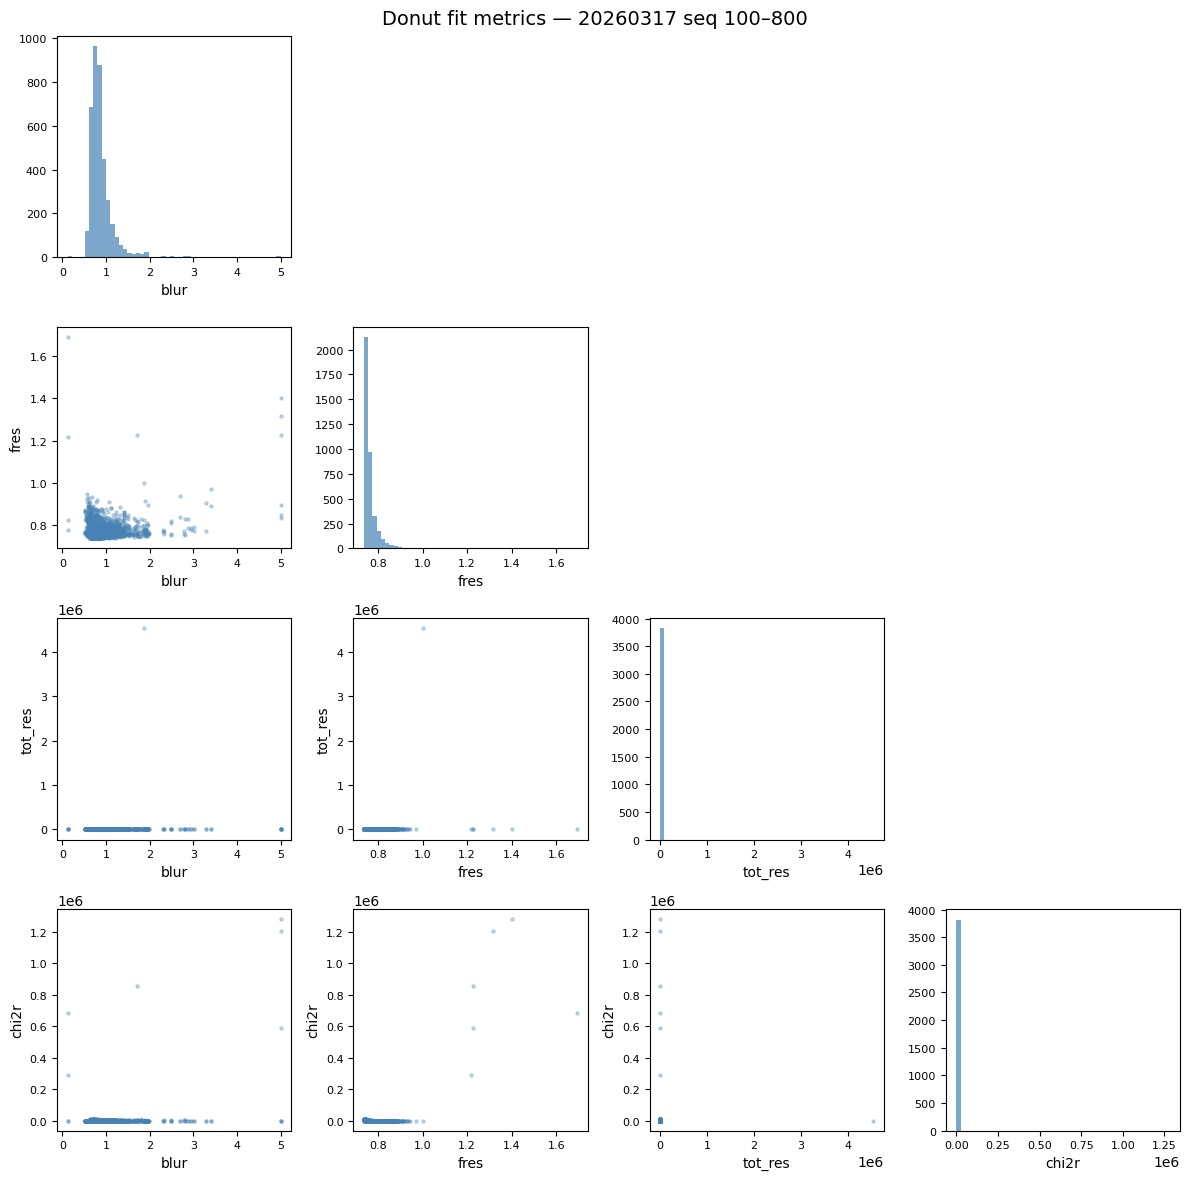

In [11]:
import numpy as np
import yaml
import danish
import galsim
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import Angle
from lsst.daf.butler import Butler
from lsst.obs.lsst import LsstCam
from lsst.ts.wep.estimation import DanishAlgorithm
from lsst.ts.wep.utils import getTaskInstrument

galsim.errors.raise_fft_size_error = True

# --- Config ---
day_obs = 20260317
seq_min = 100
seq_max = 800
ndonuts = 8

butler = Butler("embargo", collections=[
    "LSSTCam/raw/all", "LSSTCam/calib", "aos_cwfs_danish_triplets_infocus",
])
camera = LsstCam().getCamera()

visit_id_min = day_obs * 100000 + seq_min
visit_id_max = day_obs * 100000 + seq_max
refs = list(butler.registry.queryDatasets(
    'aggregateAOSVisitTableRaw', day_obs=day_obs,
    where=f"instrument='LSSTCam' and visit in ({visit_id_min}..{visit_id_max})",
).expanded())
print(f"Found {len(refs)} visits")

# --- Setup danish ---
mask_params_fn = Path(danish.datadir) / "RubinObsc.yaml"
with open(mask_params_fn) as f:
    mask_params = yaml.safe_load(f)
instrument = getTaskInstrument("LSSTCam", "R00_SW0", None)
danish_algo = DanishAlgorithm()
danish_model_keys = ["fwhm", "model_bkg", "model_dx", "model_dy", "model_flux"]

def get_rtp(donutStamps):
    md = donutStamps.metadata
    try:
        return Angle(md["BORESIGHT_PAR_ANGLE_RAD"] - md["BORESIGHT_ROT_ANGLE_RAD"] - np.pi/2, "rad")
    except KeyError:
        return Angle(np.nan, "rad")

def compute_chi2(img, model, background_std, gain=1.0):
    bg_var = background_std**2
    variance = np.clip(model, 0, None) / gain + bg_var
    mask = variance > 0
    chi2 = np.sum((img[mask] - model[mask])**2 / variance[mask])
    ndof = int(np.sum(mask)) - 1
    return chi2 / ndof if ndof > 0 else np.nan

def compute_fres(img, model):
    total = np.sum(np.abs(img))
    return np.sum(np.abs(img - model)) / total if total > 0 else np.nan

def get_model(zk_dev_ccs, zk_int_ccs, noll_indices, dmeta, stamp_extra, stamp_intra, fac):
    zk_dev = zk_dev_ccs * 1e-6
    zk_int = zk_int_ccs * 1e-6
    dz_terms = [(1, j) for j in noll_indices]
    img_e, ang_e, zkR_e, bg_e = danish_algo._prepDanish(
        image=stamp_extra.wep_im, zkStart=zk_int, nollIndices=noll_indices, instrument=instrument)
    img_i, ang_i, zkR_i, bg_i = danish_algo._prepDanish(
        image=stamp_intra.wep_im, zkStart=zk_int, nollIndices=noll_indices, instrument=instrument)
    zk_fit = zk_dev - zk_int
    nbkg = dmeta["model_bkg"].shape[1]
    bkg_order = int(np.sqrt(9 + 8*(nbkg-1)) - 3) // 2
    model = danish.DZMultiDonutModel(
        fac, z_refs=[zkR_e, zkR_i], dz_terms=dz_terms, field_radius=np.deg2rad(1.81),
        thxs=[ang_e[0], ang_i[0]], thys=[ang_e[1], ang_i[1]],
        npix=img_e.shape[0], bkg_order=bkg_order)
    bkgs = [tuple(b) for b in dmeta["model_bkg"]]
    try:
        mod_imgs = model.model(dmeta["model_flux"], dmeta["model_dx"],
                               dmeta["model_dy"], dmeta["fwhm"], zk_fit, bkgs=bkgs)
    except (galsim.GalSimFFTSizeError, ValueError):
        mod_imgs = [np.zeros_like(img_e), np.zeros_like(img_i)]
    return [img_e, img_i], mod_imgs, [bg_e, bg_i]

# --- Collect metrics ---
records = []

for iref, ref in enumerate(refs):
    visit_id = ref.dataId["visit"]
    seq_num = visit_id - day_obs * 100000
    dataId = {"instrument": "LSSTCam", "visit": visit_id}

    try:
        aos_raw = butler.get(ref)
        dsIntra = butler.get("donutStampsIntraVisit", dataId=dataId)
        dsExtra = butler.get("donutStampsExtraVisit", dataId=dataId)
    except Exception as e:
        print(f"  seq {seq_num}: skip ({e})")
        continue

    rtp = get_rtp(dsExtra)
    fac = danish.DonutFactory(
        R_outer=instrument.radius, R_inner=instrument.radius * instrument.obscuration,
        mask_params=mask_params, focal_length=instrument.focalLength,
        pixel_scale=instrument.pixelSize, spider_angle=rtp.deg)

    noll_indices = aos_raw.meta["nollIndices"]
    donut_blur = np.zeros(len(aos_raw))
    if "fwhm" in aos_raw.meta["estimatorInfo"]:
        donut_blur = np.array(aos_raw.meta["estimatorInfo"]["fwhm"])

    for raft in ["R00", "R04", "R40", "R44"]:
        sel = aos_raw["detector"] == f"{raft}_SW0"
        rows = aos_raw[sel]
        bl = donut_blur[sel]
        if len(rows) == 0:
            continue

        idxI = np.array(dsIntra.metadata.getArray("DET_NAME")) == f"{raft}_SW1"
        sI = np.array(dsIntra)[idxI]
        ix = [s.centroid_position.x for s in sI]
        iy = [s.centroid_position.y for s in sI]
        idxE = np.array(dsExtra.metadata.getArray("DET_NAME")) == f"{raft}_SW0"
        sE = np.array(dsExtra)[idxE]
        ex_ = [s.centroid_position.x for s in sE]
        ey_ = [s.centroid_position.y for s in sE]
        raft_meta = {k: np.array(v)[sel] for k, v in aos_raw.meta["estimatorInfo"].items()}

        for irow, row in enumerate(rows[:min(ndonuts, len(rows))]):
            if set(danish_model_keys) - set(row.meta["estimatorInfo"].keys()):
                continue

            d = np.hypot(np.array(ix) - row["centroid_x_intra"], np.array(iy) - row["centroid_y_intra"])
            intra_stamp = sI[np.argmin(d)]
            d = np.hypot(np.array(ex_) - row["centroid_x_extra"], np.array(ey_) - row["centroid_y_extra"])
            extra_stamp = sE[np.argmin(d)]

            dmeta = {k: v[irow] for k, v in raft_meta.items()}
            imgs, mods, bgs = get_model(
                row["zk_deviation_CCS"], row["zk_intrinsic_CCS"],
                noll_indices, dmeta, extra_stamp, intra_stamp, fac)

            for k, label in enumerate(["extra", "intra"]):
                rchi2 = compute_chi2(imgs[k], mods[k], bgs[k])
                fres = compute_fres(imgs[k], mods[k])
                im_n = imgs[k] / np.sum(imgs[k]) if np.sum(imgs[k]) > 0 else imgs[k]
                mo_n = mods[k] / np.sum(mods[k]) if np.sum(mods[k]) > 0 else mods[k]
                tot_res = np.sum(np.abs(im_n - mo_n))
                records.append(dict(
                    seq=seq_num, raft=raft, donut=irow, defocal=label,
                    blur=bl[irow], chi2r=rchi2, fres=fres, tot_res=tot_res,
                ))

    print(f"  [{iref+1}/{len(refs)}] seq {seq_num}: "
          f"{sum(1 for r in records if r['seq']==seq_num)} donuts")

df = pd.DataFrame(records)
print(f"\nTotal: {len(df)} measurements across {df['seq'].nunique()} visits")



In [13]:
from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook
output_notebook()

metrics = ["blur", "fres", "tot_res", "chi2r"]
n = len(metrics)

source = ColumnDataSource(df[metrics].dropna())

plots = []
for i in range(n):
    row = []
    for j in range(n):
        if j > i:
            row.append(None)
            continue

        p = figure(width=250, height=250,
                   tools="pan,wheel_zoom,box_zoom,reset,hover",
                   x_axis_label=metrics[j] if i == n-1 else "",
                   y_axis_label=metrics[i] if j == 0 else "")

        if i == j:
            hist, edges = np.histogram(df[metrics[i]].dropna(), bins=50)
            p.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:],
                   fill_color="steelblue", fill_alpha=0.7, line_color="white")
        else:
            p.scatter(metrics[j], metrics[i], source=source,
                      size=4, alpha=0.3, color="steelblue")

        p.title.text = f"{metrics[i]} vs {metrics[j]}" if i != j else metrics[i]
        p.title.text_font_size = "8pt"
        row.append(p)
    plots.append(row)

grid = gridplot(plots, merge_tools=True)
show(grid)

Loading BokehJS ...